• 20% of training data (low-data regime)

• 50% of training data (moderate regime)

• 100% of training data (full-data regime)

• Resize images to 224 × 224

• Normalize based on model requirements 

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR='Dataset'

print(DEVICE)

cuda


In [2]:
def loaddata(split=0.7,batchsize=16):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        # transforms.Grayscale(num_output_channels=1),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    #==========================
    dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

    if len(dataset) == 0: raise ValueError(f"No images found in the dataset directory: {DATA_DIR}. Please ensure it contains class subdirectories with images.")

    total_samples = len(dataset)

    train_size = int(split * total_samples)
    val_size = int( ((1-split)/2) * total_samples)
    test_size = total_samples - train_size - val_size

    adjusted_sizes = [train_size, val_size, test_size]
    current_sum = sum(adjusted_sizes)

    if current_sum != total_samples:
        diff = total_samples - current_sum
        test_size = max(0, test_size + diff)

    if total_samples > 0:
        if train_size == 0 and total_samples > 0: train_size = 1
        if val_size == 0 and total_samples - train_size > 0: val_size = 1
        if test_size == 0 and total_samples - train_size - val_size > 0: test_size = 1

        current_sum = train_size + val_size + test_size
        if current_sum > total_samples:
            test_size = max(0, test_size - (current_sum - total_samples))
        elif current_sum < total_samples:

            test_size += (total_samples - current_sum)

        train_size = max(0, train_size)
        val_size = max(0, val_size)
        test_size = max(0, test_size)
    else:
        train_size, val_size, test_size = 0, 0, 0

    if total_samples == 0:
        train_data, val_data, test_data = [], [], []
    elif total_samples == 1:
        train_data, val_data, test_data = random_split(dataset, [1, 0, 0])
    elif total_samples == 2:
        train_data, val_data, test_data = random_split(dataset, [1, 1, 0])
    elif total_samples == 3:
        train_data, val_data, test_data = random_split(dataset, [1, 1, 1])
    else:
        train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])


    print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)} (Total: {total_samples})")

    train_loader = DataLoader(train_data, batch_size=batchsize, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batchsize)
    test_loader = DataLoader(test_data, batch_size=batchsize)

    print("Classes:", dataset.classes)
    return dataset.classes,  train_loader,val_loader,test_loader

#===============
loaddata()

Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']


(['Knee OA', 'No-Knee OA'],
 <torch.utils.data.dataloader.DataLoader at 0x1c2bd12a550>)

Model

In [31]:
#load DinoV2 model
#MLP classifier
#    Linear → ReLU → Dropout → Linear → Softmax
import torch
# from dinov2.models import build_model_from_cfg
# from dinov2.configs import load_and_merge_config

class HIdino(torch.nn.Module):
    def __init__(self,unfrozen=False):
        super(HIdino, self).__init__()
        # cfg = load_and_merge_config("eval/vits14_pretrain")
        # self.basemodel, teacher, FeatureSize= build_model_from_cfg(cfg)
        # self.modelHead = self.basemodel.head    #backupcopy
        # self.basemodel.head = torch.nn.Identity()  # remove classification head
        self.basemodel = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(DEVICE)
        self.modelHead = getattr(self.basemodel, "head", None)
        if hasattr(self.basemodel, "head"): self.basemodel.head = nn.Identity()
        
        if unfrozen:
            for param in self.basemodel.parameters():
                param.require_grad = True
        else:
            for param in self.basemodel.parameters():
                param.require_grad = False
        
        # FeatureSize = self.basemodel.embed_dim
        # print(FeatureSize)
        #----
        self.merge_head = torch.nn.Sequential(
                            torch.nn.LayerNorm(384),
                            torch.nn.Linear(384, 128),
                            torch.nn.ReLU(),
                            torch.nn.Dropout(0.3),
                            torch.nn.Linear(128, 1),
                            # torch.nn.Softmax(dim=1)
                            ).to(DEVICE)
    #===========
    def forward(self,Imgs):
        # print('Imgs',Imgs.shape)
        imgFeat= self.basemodel(Imgs.to(DEVICE))#.unsqueeze(1).to(DEVICE)
        # print('imgFeat',imgFeat.shape)
        return self.merge_head(imgFeat).squeeze(1).float().to(DEVICE)
# HIdino()

• Loss: Cross-Entropy

• Optimizer: AdamW

• Batch size: 16 (recommended)

• Epochs: 10–20

• Early stopping based on validation

[DO FOR 20 50 100 % split]

• Accuracy

• Precision

• Recall

• F1-score

• Macro-F1 (important)

• ROC-AUC

In [35]:
def runmodel(split=0.7,batchsize=16,epochs=10,learnrate=0.001,unfrozen=False):
    model = HIdino(unfrozen)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnrate)
    classes,train_loader,val_loader,test_loader = loaddata(split,batchsize)
    
    #===================
    #Train
    #===================
    train_losses = [];val_losses = []
    if len(train_loader) > 0:
        for epoch in range(epochs):
            model.train()
            running_loss = 0
            for images, labels in train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                optimizer.zero_grad()
                outputs = model(images)
                # print(outputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            train_loss = running_loss / len(train_loader)
            train_losses.append(train_loss)
            
            #------
            #validation
            model.eval()
            val_loss = 0
            if len(val_loader) > 0:
                with torch.no_grad():
                    for images, labels in val_loader:
                        images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                        val_loss += loss.item()

                val_loss /= len(val_loader)
                val_losses.append(val_loss)
            else:
                val_losses.append(None)
                print("No validation data available for this epoch.")

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss if val_loss is not None else 'N/A' :.4f}")
    else: print(" No training data available. Skipping training loop.")
    
    #===================
    #Test
    #===================
    model.eval()
    all_preds = []
    all_labels = []

    if len(test_loader) > 0:
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(DEVICE)
                outputs = model(images)
                # _, preds = torch.max(outputs, 1)
                preds=torch.sigmoid(outputs)
                preds = (preds>=0.5).float()
                # print(preds)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        if len(all_labels) > 0:
            print("\nConfusion Matrix:")
            cm = confusion_matrix(all_labels, all_preds, labels=np.arange(len(classes)))
            
            plt.clf()
            plt.figure()
            sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title("Confusion Matrix")
            plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___CM.png")
            # plt.show()

            print("\nClassification Report:")
            print(classification_report(all_labels, all_preds, target_names=classes, labels=np.arange(len(classes))))
        else: print("Test data loader was not empty, but no predictions or labels were collected.")
    else: print("No test data available.")
    
    #===================
    #Loss Curve
    #===================
    valid_val_losses = [l for l in val_losses if l is not None]

    if train_losses or valid_val_losses:
        plt.clf()
        plt.figure()
        plt.plot(train_losses, label="Train Loss")
        plt.plot(valid_val_losses, label="Validation Loss")
        plt.legend()
        plt.title("Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___LC.png")
        # plt.show()
    else: print("No loss data to plot.")
    
    #===================
    #ROC Curve
    #===================
    fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
    auc_score = roc_auc_score(all_labels, all_preds)
    print("ROC-AUC:", auc_score)

    # Plot ROC curve
    plt.clf()
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___ROC.png")
    # plt.show()
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001)
# runmodel(split=0.7,batchsize=16,epochs=3,learnrate=0.0000001)
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001,unfrozen=False)
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001,unfrozen=True)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/15 | Train Loss: 88.4217 | Val Loss: 31.8310
Epoch 2/15 | Train Loss: 31.0027 | Val Loss: 31.8310
Epoch 3/15 | Train Loss: 31.0027 | Val Loss: 31.8310
Epoch 4/15 | Train Loss: 31.0039 | Val Loss: 31.8310
Epoch 5/15 | Train Loss: 31.0016 | Val Loss: 31.8310
Epoch 6/15 | Train Loss: 31.0050 | Val Loss: 31.8310
Epoch 7/15 | Train Loss: 31.0062 | Val Loss: 31.8310
Epoch 8/15 | Train Loss: 31.0073 | Val Loss: 31.8310
Epoch 9/15 | Train Loss: 31.0039 | Val Loss: 31.8310
Epoch 10/15 | Train Loss: 31.0073 | Val Loss: 31.8310
Epoch 11/15 | Train Loss: 31.0073 | Val Loss: 31.8310
Epoch 12/15 | Train Loss: 31.0050 | Val Loss: 31.8310
Epoch 13/15 | Train Loss: 31.0050 | Val Loss: 31.8310
Epoch 14/15 | Train Loss: 31.0050 | Val Loss: 31.8310
Epoch 15/15 | Train Loss: 31.0073 | Val Loss: 31.8310

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       

c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/15 | Train Loss: 31.2722 | Val Loss: 31.2623
Epoch 2/15 | Train Loss: 31.0964 | Val Loss: 31.2623
Epoch 3/15 | Train Loss: 31.0976 | Val Loss: 31.2623
Epoch 4/15 | Train Loss: 31.0976 | Val Loss: 31.2623
Epoch 5/15 | Train Loss: 31.0964 | Val Loss: 31.2623
Epoch 6/15 | Train Loss: 31.0976 | Val Loss: 31.2623
Epoch 7/15 | Train Loss: 31.0987 | Val Loss: 31.2623
Epoch 8/15 | Train Loss: 31.0964 | Val Loss: 31.2623
Epoch 9/15 | Train Loss: 31.0953 | Val Loss: 31.2623
Epoch 10/15 | Train Loss: 31.0976 | Val Loss: 31.2623
Epoch 11/15 | Train Loss: 31.0987 | Val Loss: 31.2623
Epoch 12/15 | Train Loss: 31.0987 | Val Loss: 31.2623
Epoch 13/15 | Train Loss: 31.0999 | Val Loss: 31.2623
Epoch 14/15 | Train Loss: 31.0976 | Val Loss: 31.2623
Epoch 15/15 | Train Loss: 31.0976 | Val Loss: 31.2623

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       

c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

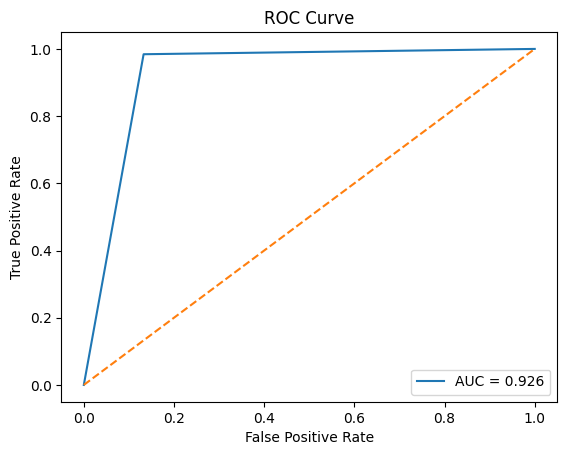

In [ ]:
#find right LR - frozen
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.1)
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.01)
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.001)
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.0001)
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.00001)
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.000001)
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.0000001)


Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/15 | Train Loss: 30.1136 | Val Loss: 28.9782
Epoch 2/15 | Train Loss: 28.7849 | Val Loss: 28.2372
Epoch 3/15 | Train Loss: 28.3618 | Val Loss: 27.9539
Epoch 4/15 | Train Loss: 28.1262 | Val Loss: 27.8659
Epoch 5/15 | Train Loss: 27.9763 | Val Loss: 27.7614
Epoch 6/15 | Train Loss: 27.8569 | Val Loss: 27.7775
Epoch 7/15 | Train Loss: 27.7825 | Val Loss: 27.7234
Epoch 8/15 | Train Loss: 27.7299 | Val Loss: 27.8344
Epoch 9/15 | Train Loss: 27.7781 | Val Loss: 27.6710
Epoch 10/15 | Train Loss: 27.7732 | Val Loss: 27.8482
Epoch 11/15 | Train Loss: 27.7560 | Val Loss: 27.7130
Epoch 12/15 | Train Loss: 27.6138 | Val Loss: 27.8000
Epoch 13/15 | Train Loss: 27.6275 | Val Loss: 27.8367
Epoch 14/15 | Train Loss: 27.7737 | Val Loss: 27.6236
Epoch 15/15 | Train Loss: 27.5852 | Val Loss: 27.9002

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

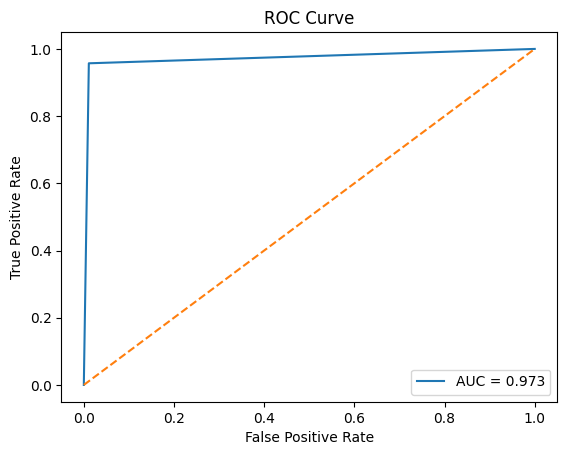

In [36]:
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.000001,unfrozen=False)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/15 | Train Loss: 30.1306 | Val Loss: 28.6096
Epoch 2/15 | Train Loss: 28.9250 | Val Loss: 28.0182
Epoch 3/15 | Train Loss: 28.5172 | Val Loss: 28.0033
Epoch 4/15 | Train Loss: 28.3642 | Val Loss: 27.7120
Epoch 5/15 | Train Loss: 28.1628 | Val Loss: 27.6439
Epoch 6/15 | Train Loss: 28.1102 | Val Loss: 27.8493
Epoch 7/15 | Train Loss: 27.9874 | Val Loss: 27.6804
Epoch 8/15 | Train Loss: 28.0527 | Val Loss: 27.8220
Epoch 9/15 | Train Loss: 27.9403 | Val Loss: 27.5196
Epoch 10/15 | Train Loss: 27.8834 | Val Loss: 27.4542
Epoch 11/15 | Train Loss: 27.8902 | Val Loss: 27.8939
Epoch 12/15 | Train Loss: 27.8633 | Val Loss: 27.4378
Epoch 13/15 | Train Loss: 27.8617 | Val Loss: 27.4309
Epoch 14/15 | Train Loss: 27.8696 | Val Loss: 27.6194
Epoch 15/15 | Train Loss: 27.7637 | Val Loss: 27.4055

Confusion Matrix:

Classification Report:
              precision    recall  f1-score   support

     Knee OA       

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

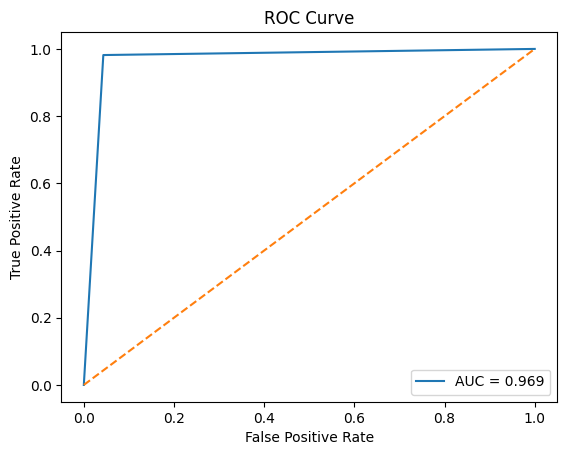

In [37]:
runmodel(split=0.7,batchsize=16,epochs=15,learnrate=0.000001,unfrozen=True)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 61.7982 | Val Loss: 31.0556
Epoch 2/20 | Train Loss: 31.1105 | Val Loss: 31.0556
Epoch 3/20 | Train Loss: 31.1105 | Val Loss: 31.0556
Epoch 4/20 | Train Loss: 31.1094 | Val Loss: 31.0556
Epoch 5/20 | Train Loss: 31.1151 | Val Loss: 31.0556
Epoch 6/20 | Train Loss: 31.1128 | Val Loss: 31.0556
Epoch 7/20 | Train Loss: 31.1117 | Val Loss: 31.0556
Epoch 8/20 | Train Loss: 31.1117 | Val Loss: 31.0556
Epoch 9/20 | Train Loss: 31.1174 | Val Loss: 31.0556
Epoch 10/20 | Train Loss: 31.1117 | Val Loss: 31.0556
Epoch 11/20 | Train Loss: 31.1117 | Val Loss: 31.0556
Epoch 12/20 | Train Loss: 31.1117 | Val Loss: 31.0556
Epoch 13/20 | Train Loss: 31.1082 | Val Loss: 31.0556
Epoch 14/20 | Train Loss: 31.1139 | Val Loss: 31.0556
Epoch 15/20 | Train Loss: 31.1162 | Val Loss: 31.0556
Epoch 16/20 | Train Loss: 31.1117 | Val Loss: 31.0556
Epoch 17/20 | Train Loss: 31.1139 | Val Loss: 31.0556
Epoch 18/

c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 31.0633 | Val Loss: 32.0410
Epoch 2/20 | Train Loss: 30.9277 | Val Loss: 32.0410
Epoch 3/20 | Train Loss: 30.9300 | Val Loss: 32.0410
Epoch 4/20 | Train Loss: 30.9311 | Val Loss: 32.0410
Epoch 5/20 | Train Loss: 30.9289 | Val Loss: 32.0410
Epoch 6/20 | Train Loss: 30.9289 | Val Loss: 32.0410
Epoch 7/20 | Train Loss: 30.9289 | Val Loss: 32.0410
Epoch 8/20 | Train Loss: 30.9323 | Val Loss: 32.0410
Epoch 9/20 | Train Loss: 30.9323 | Val Loss: 32.0410
Epoch 10/20 | Train Loss: 30.9300 | Val Loss: 32.0410
Epoch 11/20 | Train Loss: 30.9266 | Val Loss: 32.0410
Epoch 12/20 | Train Loss: 30.9289 | Val Loss: 32.0410
Epoch 13/20 | Train Loss: 30.9266 | Val Loss: 32.0410
Epoch 14/20 | Train Loss: 30.9300 | Val Loss: 32.0410
Epoch 15/20 | Train Loss: 30.9289 | Val Loss: 32.0410
Epoch 16/20 | Train Loss: 30.9311 | Val Loss: 32.0410
Epoch 17/20 | Train Loss: 30.9266 | Val Loss: 32.0410
Epoch 18/

c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\jump3\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

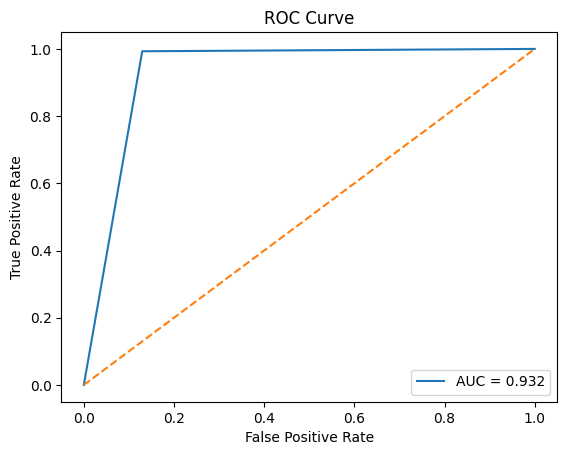

In [39]:
#find right LR - frozen
runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=True,learnrate=0.1)
runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=True,learnrate=0.01)
runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=True,learnrate=0.001)
runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=True,learnrate=0.0001)
runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=True,learnrate=0.00001)
runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=True,learnrate=0.000001)
runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=True,learnrate=0.0000001)

In [ ]:
# #find right LR - unfrozen
# runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=False,learnrate=0.1)
# runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=False,learnrate=0.01)
# runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=False,learnrate=0.001)
# runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=False,learnrate=0.0001)
# runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=False,learnrate=0.00001)
# runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=False,learnrate=0.000001)
# runmodel(split=0.7,batchsize=16,epochs=20,unfrozen=False,learnrate=0.0000001)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 831, Val: 1662, Test: 1663 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 31.0141 | Val Loss: 31.3469
Epoch 2/20 | Train Loss: 30.0450 | Val Loss: 30.4245
Epoch 3/20 | Train Loss: 29.1599 | Val Loss: 30.2578
Epoch 4/20 | Train Loss: 29.0277 | Val Loss: 29.8073
Epoch 5/20 | Train Loss: 28.6284 | Val Loss: 29.3469
Epoch 6/20 | Train Loss: 28.5597 | Val Loss: 29.2827
Epoch 7/20 | Train Loss: 28.1609 | Val Loss: 29.0868
Epoch 8/20 | Train Loss: 27.9688 | Val Loss: 29.2053
Epoch 9/20 | Train Loss: 28.1054 | Val Loss: 29.0815
Epoch 10/20 | Train Loss: 28.0422 | Val Loss: 29.0824
Epoch 11/20 | Train Loss: 27.8728 | Val Loss: 29.0844
Epoch 12/20 | Train Loss: 27.8586 | Val Loss: 29.1124
Epoch 13/20 | Train Loss: 27.7260 | Val Loss: 29.3462
Epoch 14/20 | Train Loss: 27.7904 | Val Loss: 29.0126
Epoch 15/20 | Train Loss: 27.7647 | Val Loss: 29.0700
Epoch 16/20 | Train Loss: 27.6407 | Val Loss: 29.0109
Epoch 17/20 | Train Loss: 27.7581 | Val Loss: 29.3505
Epoch 18

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

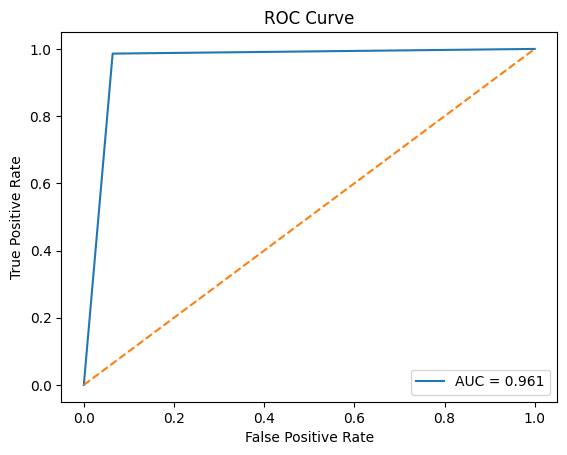

In [40]:
#run 20 - frozen
runmodel(split=0.2,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 2078, Val: 1039, Test: 1039 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 30.2290 | Val Loss: 29.5092
Epoch 2/20 | Train Loss: 28.8615 | Val Loss: 28.8474
Epoch 3/20 | Train Loss: 28.4143 | Val Loss: 28.5847
Epoch 4/20 | Train Loss: 28.1424 | Val Loss: 28.5208
Epoch 5/20 | Train Loss: 28.0907 | Val Loss: 28.5323
Epoch 6/20 | Train Loss: 28.1056 | Val Loss: 28.3586
Epoch 7/20 | Train Loss: 27.8806 | Val Loss: 28.3668
Epoch 8/20 | Train Loss: 27.7939 | Val Loss: 28.2794
Epoch 9/20 | Train Loss: 27.7295 | Val Loss: 28.2965
Epoch 10/20 | Train Loss: 27.6942 | Val Loss: 28.1634
Epoch 11/20 | Train Loss: 27.6793 | Val Loss: 28.4848
Epoch 12/20 | Train Loss: 27.5558 | Val Loss: 28.2103
Epoch 13/20 | Train Loss: 27.5570 | Val Loss: 28.0142
Epoch 14/20 | Train Loss: 27.5966 | Val Loss: 28.1349
Epoch 15/20 | Train Loss: 27.5936 | Val Loss: 28.0873
Epoch 16/20 | Train Loss: 27.4796 | Val Loss: 28.2275
Epoch 17/20 | Train Loss: 27.4737 | Val Loss: 28.1379
Epoch 1

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

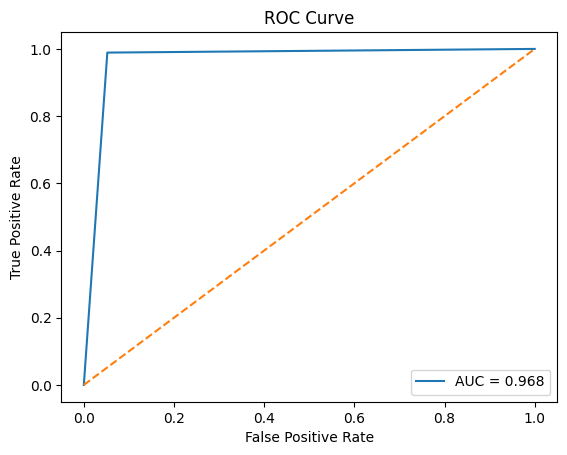

In [41]:
#run 50 - frozen
runmodel(split=0.5,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.8496 | Val Loss: 29.8669
Epoch 2/20 | Train Loss: 28.6092 | Val Loss: 29.6076
Epoch 3/20 | Train Loss: 28.1276 | Val Loss: 29.4783
Epoch 4/20 | Train Loss: 27.9854 | Val Loss: 29.7308
Epoch 5/20 | Train Loss: 27.9121 | Val Loss: 29.3761
Epoch 6/20 | Train Loss: 27.9209 | Val Loss: 29.3328
Epoch 7/20 | Train Loss: 27.7663 | Val Loss: 29.1550
Epoch 8/20 | Train Loss: 27.7100 | Val Loss: 29.3932
Epoch 9/20 | Train Loss: 27.7918 | Val Loss: 29.2111
Epoch 10/20 | Train Loss: 27.7144 | Val Loss: 29.2342
Epoch 11/20 | Train Loss: 27.5787 | Val Loss: 29.3515
Epoch 12/20 | Train Loss: 27.5788 | Val Loss: 29.1465
Epoch 13/20 | Train Loss: 27.6158 | Val Loss: 29.2895
Epoch 14/20 | Train Loss: 27.5652 | Val Loss: 29.1393
Epoch 15/20 | Train Loss: 27.5576 | Val Loss: 29.2422
Epoch 16/20 | Train Loss: 27.5391 | Val Loss: 29.2132
Epoch 17/20 | Train Loss: 27.4971 | Val Loss: 29.2280
Epoch 18/

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

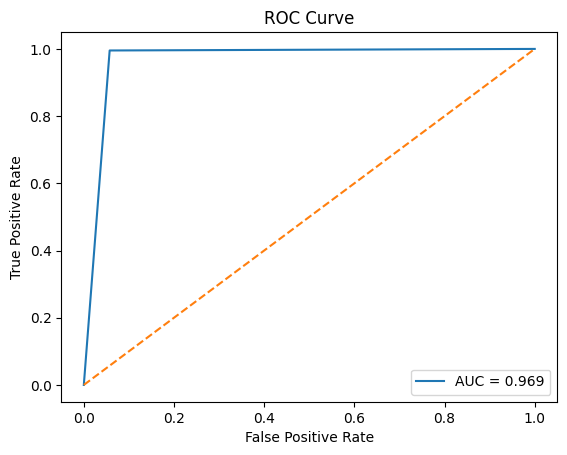

In [42]:
#run 70 - unfrozen
runmodel(split=0.7,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 4072, Val: 41, Test: 43 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.7680 | Val Loss: 22.9715
Epoch 2/20 | Train Loss: 28.5690 | Val Loss: 22.9768
Epoch 3/20 | Train Loss: 28.3472 | Val Loss: 22.6833
Epoch 4/20 | Train Loss: 28.1071 | Val Loss: 22.5960
Epoch 5/20 | Train Loss: 28.0083 | Val Loss: 22.5078
Epoch 6/20 | Train Loss: 27.9309 | Val Loss: 22.6886
Epoch 7/20 | Train Loss: 27.8743 | Val Loss: 22.6463
Epoch 8/20 | Train Loss: 27.8418 | Val Loss: 22.4200
Epoch 9/20 | Train Loss: 27.8187 | Val Loss: 22.5894
Epoch 10/20 | Train Loss: 27.7695 | Val Loss: 22.4074
Epoch 11/20 | Train Loss: 27.7637 | Val Loss: 22.4207
Epoch 12/20 | Train Loss: 27.6760 | Val Loss: 22.4148
Epoch 13/20 | Train Loss: 27.7257 | Val Loss: 22.6496
Epoch 14/20 | Train Loss: 27.7490 | Val Loss: 22.3663
Epoch 15/20 | Train Loss: 27.6935 | Val Loss: 22.3704
Epoch 16/20 | Train Loss: 27.6023 | Val Loss: 22.7092
Epoch 17/20 | Train Loss: 27.6926 | Val Loss: 22.3718
Epoch 18/20

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

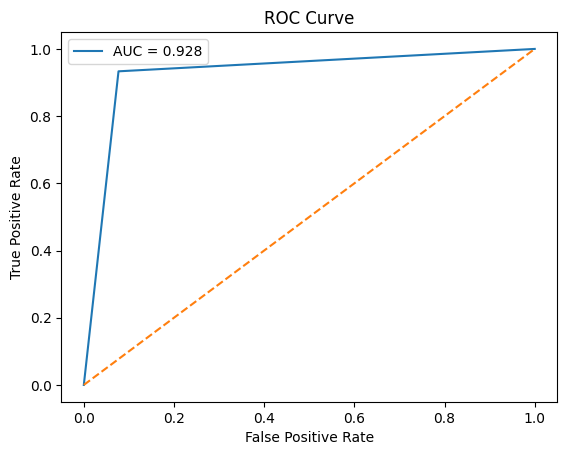

In [44]:
#run 100 - frozen
runmodel(split=0.98,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)

unfrozen

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 831, Val: 1662, Test: 1663 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 31.3734 | Val Loss: 30.5121
Epoch 2/20 | Train Loss: 30.4036 | Val Loss: 29.8696
Epoch 3/20 | Train Loss: 29.9727 | Val Loss: 29.4487
Epoch 4/20 | Train Loss: 29.6110 | Val Loss: 29.3322
Epoch 5/20 | Train Loss: 29.3738 | Val Loss: 29.0540
Epoch 6/20 | Train Loss: 29.1637 | Val Loss: 29.0011
Epoch 7/20 | Train Loss: 29.1685 | Val Loss: 28.8188
Epoch 8/20 | Train Loss: 29.0052 | Val Loss: 28.8510
Epoch 9/20 | Train Loss: 28.9143 | Val Loss: 29.0398
Epoch 10/20 | Train Loss: 28.7788 | Val Loss: 28.6980
Epoch 11/20 | Train Loss: 28.7494 | Val Loss: 29.0310
Epoch 12/20 | Train Loss: 28.7837 | Val Loss: 28.6699
Epoch 13/20 | Train Loss: 28.6831 | Val Loss: 28.6879
Epoch 14/20 | Train Loss: 28.6197 | Val Loss: 28.6024
Epoch 15/20 | Train Loss: 28.4328 | Val Loss: 28.4698
Epoch 16/20 | Train Loss: 28.6198 | Val Loss: 28.5747
Epoch 17/20 | Train Loss: 28.5212 | Val Loss: 28.5395
Epoch 18

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

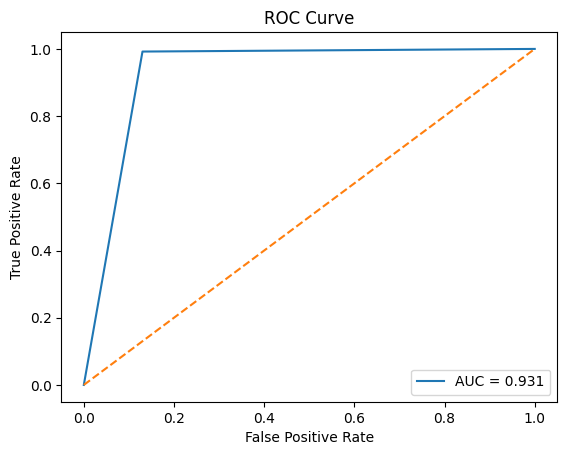

In [45]:
#run 20 - unfrozen
runmodel(split=0.2,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=True)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 831, Val: 1662, Test: 1663 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 30.3827 | Val Loss: 30.2134
Epoch 2/20 | Train Loss: 29.2790 | Val Loss: 29.2019
Epoch 3/20 | Train Loss: 28.5352 | Val Loss: 28.9961
Epoch 4/20 | Train Loss: 28.3786 | Val Loss: 29.2802
Epoch 5/20 | Train Loss: 28.2756 | Val Loss: 28.5074
Epoch 6/20 | Train Loss: 27.9232 | Val Loss: 28.3952
Epoch 7/20 | Train Loss: 27.7916 | Val Loss: 28.3649
Epoch 8/20 | Train Loss: 27.4576 | Val Loss: 28.1524
Epoch 9/20 | Train Loss: 27.3805 | Val Loss: 28.1074
Epoch 10/20 | Train Loss: 27.3646 | Val Loss: 28.2546
Epoch 11/20 | Train Loss: 27.3469 | Val Loss: 28.4058
Epoch 12/20 | Train Loss: 27.4088 | Val Loss: 28.4723
Epoch 13/20 | Train Loss: 27.2435 | Val Loss: 28.0285
Epoch 14/20 | Train Loss: 27.3179 | Val Loss: 28.0221
Epoch 15/20 | Train Loss: 27.1773 | Val Loss: 28.0538
Epoch 16/20 | Train Loss: 27.2111 | Val Loss: 27.8887
Epoch 17/20 | Train Loss: 27.2049 | Val Loss: 28.0227
Epoch 18

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

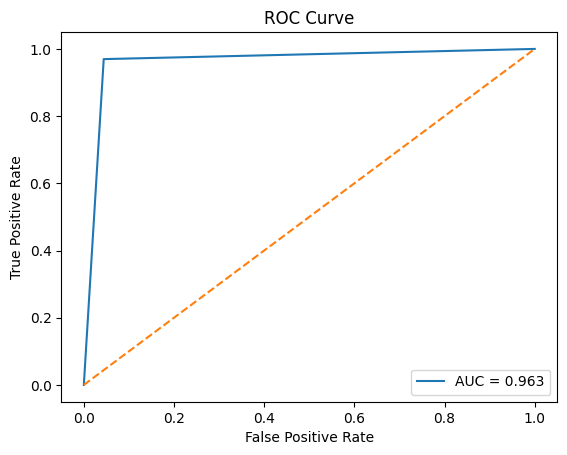

In [46]:
#run 50 - unfrozen
runmodel(split=0.2,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=True)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 2909, Val: 623, Test: 624 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.7622 | Val Loss: 29.5040
Epoch 2/20 | Train Loss: 28.5832 | Val Loss: 28.5890
Epoch 3/20 | Train Loss: 28.3090 | Val Loss: 28.8042
Epoch 4/20 | Train Loss: 27.9439 | Val Loss: 28.4855
Epoch 5/20 | Train Loss: 27.7845 | Val Loss: 28.4058
Epoch 6/20 | Train Loss: 27.8732 | Val Loss: 28.2416
Epoch 7/20 | Train Loss: 27.7423 | Val Loss: 28.2531
Epoch 8/20 | Train Loss: 27.6273 | Val Loss: 28.0828
Epoch 9/20 | Train Loss: 27.5245 | Val Loss: 28.0933
Epoch 10/20 | Train Loss: 27.6335 | Val Loss: 28.3108
Epoch 11/20 | Train Loss: 27.6536 | Val Loss: 28.0773
Epoch 12/20 | Train Loss: 27.5757 | Val Loss: 28.1002
Epoch 13/20 | Train Loss: 27.3748 | Val Loss: 27.9927
Epoch 14/20 | Train Loss: 27.4810 | Val Loss: 28.0743
Epoch 15/20 | Train Loss: 27.4688 | Val Loss: 28.1280
Epoch 16/20 | Train Loss: 27.3907 | Val Loss: 28.0914
Epoch 17/20 | Train Loss: 27.3026 | Val Loss: 28.2845
Epoch 18/

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

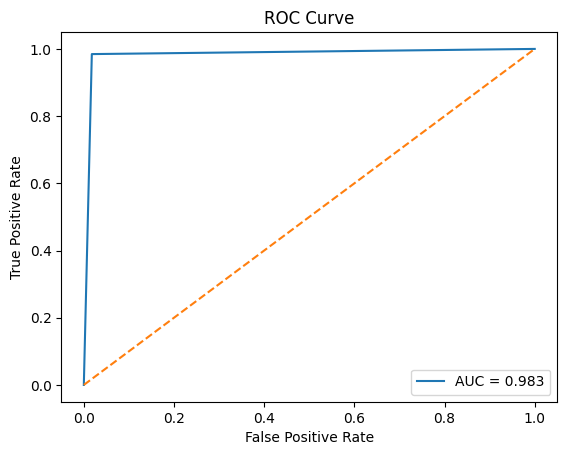

In [47]:
#run 70 - unfrozen
runmodel(split=0.7,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=True)

Using cache found in C:\Users\jump3/.cache\torch\hub\facebookresearch_dinov2_main


Train: 4072, Val: 41, Test: 43 (Total: 4156)
Classes: ['Knee OA', 'No-Knee OA']
Epoch 1/20 | Train Loss: 29.6419 | Val Loss: 24.2147
Epoch 2/20 | Train Loss: 28.4380 | Val Loss: 24.0704
Epoch 3/20 | Train Loss: 28.2009 | Val Loss: 23.8340
Epoch 4/20 | Train Loss: 27.9931 | Val Loss: 23.5524
Epoch 5/20 | Train Loss: 27.8788 | Val Loss: 23.5328
Epoch 6/20 | Train Loss: 27.7432 | Val Loss: 23.5428
Epoch 7/20 | Train Loss: 27.8398 | Val Loss: 23.5303
Epoch 8/20 | Train Loss: 27.7367 | Val Loss: 23.7391
Epoch 9/20 | Train Loss: 27.7615 | Val Loss: 23.6146
Epoch 10/20 | Train Loss: 27.6830 | Val Loss: 23.4981
Epoch 11/20 | Train Loss: 27.6677 | Val Loss: 23.4988
Epoch 12/20 | Train Loss: 27.6614 | Val Loss: 24.2903
Epoch 13/20 | Train Loss: 27.6668 | Val Loss: 23.7483
Epoch 14/20 | Train Loss: 27.6121 | Val Loss: 23.5012
Epoch 15/20 | Train Loss: 27.5887 | Val Loss: 23.4930
Epoch 16/20 | Train Loss: 27.6496 | Val Loss: 23.6372
Epoch 17/20 | Train Loss: 27.6128 | Val Loss: 23.4994
Epoch 18/20

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

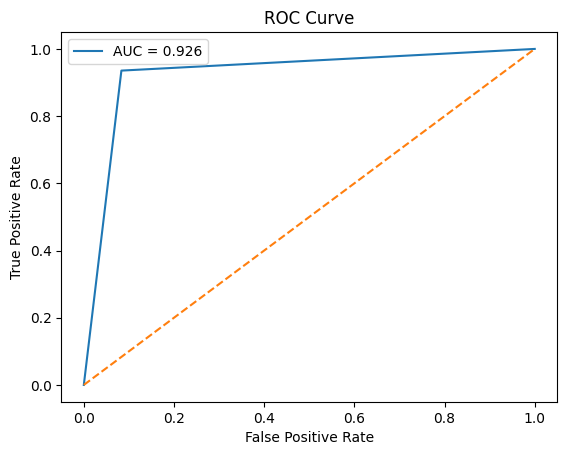

In [48]:
#run 100 - unfrozen
runmodel(split=0.98,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=True)

Remake, dont use a validation or testing split

In [ ]:
def runmodel_final(split=0.7,batchsize=16,epochs=10,learnrate=0.001,unfrozen=False):
    model = HIdino(unfrozen)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learnrate)
    classes,train_loader,val_loader,test_loader = loaddata(split,batchsize)
    
    #===================
    #Train
    #===================
    train_losses = [];val_losses = []
    if len(train_loader) > 0:
        for epoch in range(epochs):
            model.train()
            running_loss = 0
            for images, labels in train_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                optimizer.zero_grad()
                outputs = model(images)
                # print(outputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            train_loss = running_loss / len(train_loader)
            train_losses.append(train_loss)

            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss if val_loss is not None else 'N/A' :.4f}")
    else: print(" No training data available. Skipping training loop.")
    
    #===================
    #Test - still training
    #===================
    model.eval()
    all_preds = []
    all_labels = []

    if len(test_loader) > 0:
        with torch.no_grad():
            for images, labels in train_loader:
                images = images.to(DEVICE)
                outputs = model(images)
                # _, preds = torch.max(outputs, 1)
                preds=torch.sigmoid(outputs)
                preds = (preds>=0.5).float()
                # print(preds)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        if len(all_labels) > 0:
            print("\nConfusion Matrix:")
            cm = confusion_matrix(all_labels, all_preds, labels=np.arange(len(classes)))
            
            plt.clf()
            plt.figure()
            sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.title("Confusion Matrix")
            plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___CM.png")
            # plt.show()

            print("\nClassification Report:")
            print(classification_report(all_labels, all_preds, target_names=classes, labels=np.arange(len(classes))))
        else: print("Test data loader was not empty, but no predictions or labels were collected.")
    else: print("No test data available.")
    
    #===================
    #Loss Curve
    #===================
    valid_val_losses = [l for l in val_losses if l is not None]

    if train_losses or valid_val_losses:
        plt.clf()
        plt.figure()
        plt.plot(train_losses, label="Train Loss")
        plt.plot(valid_val_losses, label="Validation Loss")
        plt.legend()
        plt.title("Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___LC.png")
        # plt.show()
    else: print("No loss data to plot.")
    
    #===================
    #ROC Curve
    #===================
    fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
    auc_score = roc_auc_score(all_labels, all_preds)
    print("ROC-AUC:", auc_score)

    # Plot ROC curve
    plt.clf()
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.savefig(f"Savefigs/sp{split*100}-bs{batchsize}-ep{epochs}-lr{learnrate}-f{int(unfrozen)}___ROC.png")
    # plt.show()
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001)
# runmodel(split=0.7,batchsize=16,epochs=3,learnrate=0.0000001)
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001,unfrozen=False)
# runmodel(split=0.7,batchsize=16,epochs=1,learnrate=0.001,unfrozen=True)

In [ ]:
#   20/30/40/50/60/70/80/90/100
runmodel(split=0.2,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.3,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.4,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.5,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.6,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.7,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.8,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.9,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)
runmodel(split=0.99,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)

In [ ]:
runmodel(split=1,batchsize=16,epochs=20,learnrate=0.000001,unfrozen=False)

In [ ]:
#   20/30/40/50/60/70/80/90/100
runmodel(split=0.2,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.3,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.4,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.5,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.6,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.7,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.8,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.9,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)
runmodel(split=0.99,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)

In [ ]:
runmodel(split=1,batchsize=16,epochs=20,learnrate=0.00001,unfrozen=True)